How Does Seasonal Energy Usage Vary Across the City of Chicago?

## Sustainability & Critical Infrastructure — Datathon 2026

---

### Problem Statement

Energy consumption is one of the largest contributors to urban carbon emissions. Understanding **how energy usage shifts with the seasons** and whether those shifts differ across neighborhoods is critical for planning sustainable infrastructure, targeting efficiency programs, and reducing peak-load strain on the grid.

**Research Question:** *How does seasonal energy usage (electricity and natural gas) vary across Chicago's community areas?*

### Hypothesis

> **H₁:** Energy usage exhibits a strong seasonal pattern—electricity consumption peaks in **summer** (driven by air conditioning) while natural gas consumption peaks in **winter** (driven by heating)—and the **magnitude of these seasonal swings differs significantly across community areas** due to differences in building age, density, and housing type.

## Dataset Description

**Source:** [Energy Consumption Patterns in Chicago – Kaggle](https://www.kaggle.com/datasets/thedevastator/analyzing-energy-consumption-patterns-in-chicago)  
**Original provider:** City of Chicago Data Portal (ComEd & Peoples Natural Gas, aggregated by Accenture)

The dataset records energy usage at the **census-block level** for the City of Chicago during **2010**. It covers approximately 88% of Chicago's buildings (68% of total electricity, 81% of total gas).

### Key columns we will use

| Column | Description |
|---|---|
| `COMMUNITY AREA NAME` | One of Chicago's 77 officially defined community areas |
| `BUILDING TYPE` | Residential, Commercial, or Industrial |
| `KWH JANUARY 2010` … `KWH DECEMBER 2010` | Monthly electricity consumption (kilowatt-hours) |
| `THERM JANUARY 2010` … `THERM DECEMBER 2010` | Monthly natural gas consumption (therms) |
| `TOTAL KWH` / `TOTAL THERMS` | Annual totals |
| `ELECTRICITY ACCOUNTS` / `GAS ACCOUNTS` | Number of utility accounts in each block |
| `TOTAL POPULATION`, `OCCUPIED UNITS`, `AVERAGE BUILDING AGE` | Census demographics & housing characteristics |

> **Note:** Census blocks with fewer than 4 accounts are aggregated to the community-area level for privacy.

## Data Cleaning & Preprocessing

In [23]:
# Install any missing packages before we import them.
# The exclamation mark (!) tells Jupyter to run this as a terminal command.
# "pip" is Python's package installer.
# "-q" means "quiet" — it suppresses most of the installation output.
# You only need to run this cell once; after that the packages stay installed.
!pip install -q seaborn

In [24]:
# ── Import all the libraries we need ─────────────────────────────────────────

# pandas: the main library for working with tabular data (like spreadsheets).
# We give it the short alias "pd" so we can write pd.read_csv() instead of pandas.read_csv().
import pandas as pd

# numpy: fast math operations on arrays and numbers.
# We use it for things like np.polyfit() (fitting a trend line).
import numpy as np

# matplotlib.pyplot: the core Python plotting library.
# "plt" is the standard short alias.
import matplotlib.pyplot as plt

# matplotlib.ticker: lets us format axis tick labels (e.g. show "5M" instead of "5000000").
import matplotlib.ticker as mticker

# seaborn: a higher-level plotting library built on top of matplotlib.
# It makes statistical charts (box plots, heatmaps) much easier to create.
import seaborn as sns

# scipy.stats: statistical functions — we use it for hypothesis tests.
from scipy import stats

# warnings: Python's built-in module for controlling warning messages.
import warnings

# Hide non-critical warning messages so the output stays clean.
warnings.filterwarnings("ignore")

# Set a clean visual style for all seaborn charts.
# "whitegrid" adds light horizontal grid lines; "colorblind" picks accessible colors.
sns.set_theme(style="whitegrid", palette="colorblind")

# Set default figure size (10 inches wide × 5 inches tall) and resolution (120 dpi).
# These apply to every matplotlib/seaborn chart unless we override them per chart.
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

# Confirm everything loaded correctly.
print("Libraries loaded ✓")

Libraries loaded ✓


In [25]:
# ── Load the dataset ─────────────────────────────────────────────────────────
# The dataset is the City of Chicago Energy Usage 2010 CSV.
# Download it from Kaggle: https://www.kaggle.com/datasets/thedevastator/analyzing-energy-consumption-patterns-in-chicago
# Save the CSV in the same folder as this notebook, then run this cell.

# DATA_PATH is just a variable holding the file name as a string.
# If your file has a different name, change the string below.
DATA_PATH = "Energy_Usage_2010.csv"

# pd.read_csv() reads the CSV file and loads it into a "DataFrame" (df).
# A DataFrame is like a spreadsheet — rows and columns you can filter, sort, and calculate on.
# We call it df_raw to remind ourselves this is the original, unmodified data.
df_raw = pd.read_csv(DATA_PATH)

# df.shape returns a tuple (number_of_rows, number_of_columns).
# The :, format adds commas to large numbers (e.g. 67,051 instead of 67051).
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")

# df.head(3) shows the first 3 rows — a quick sanity check that the data loaded correctly.
df_raw.head(3)

Rows: 67,051  |  Columns: 73


,COMMUNITY AREA NAME,CENSUS BLOCK,BUILDING TYPE,BUILDING_SUBTYPE,KWH JANUARY 2010,KWH FEBRUARY 2010,KWH MARCH 2010,KWH APRIL 2010,KWH MAY 2010,KWH JUNE 2010,...,TOTAL POPULATION,TOTAL UNITS,AVERAGE STORIES,AVERAGE BUILDING AGE,AVERAGE HOUSESIZE,OCCUPIED UNITS,OCCUPIED UNITS PERCENTAGE,RENTER-OCCUPIED HOUSING UNITS,RENTER-OCCUPIED HOUSING PERCENTAGE,OCCUPIED HOUSING UNITS
0,Archer Heights,1.703157e+14,Residential,Multi < 7,NaN,NaN,NaN,NaN,NaN,NaN,...,89.0,24.0,2.0,71.33,3.87,23.0,0.9582,9.0,0.3910,23.0
1,Ashburn,1.703170e+14,Residential,Multi 7+,7334.0,7741.0,4214.0,4284.0,2518.0,4273.0,...,112.0,67.0,2.0,41.00,1.81,62.0,0.9254,50.0,0.8059,62.0
2,Auburn Gresham,1.703171e+14,Commercial,Multi < 7,NaN,NaN,NaN,NaN,NaN,NaN,...,102.0,48.0,3.0,86.00,3.00,34.0,0.7082,23.0,0.6759,34.0


In [26]:
# ── Quick data-quality check ─────────────────────────────────────────────────
# Before doing any analysis, it is good practice to understand:
#   1. What types of data are in each column (numbers vs. text)
#   2. How many values are missing (NaN = "Not a Number", Python's way of saying "blank")

# --- Part 1: Data types ---
print("Data types:\n")
# df.dtypes gives the data type of every column.
# .value_counts() counts how many columns have each type (e.g. 50 numeric, 5 text).
print(df_raw.dtypes.value_counts())

# --- Part 2: Missing values ---
print(f"\nMissing values (top 15):\n")
# df.isnull() returns True/False for every cell — True means the value is missing.
# .sum() adds up the True values per column (True counts as 1, False as 0).
missing = df_raw.isnull().sum()

# Filter to only columns that have at least one missing value, then sort descending.
# .head(15) shows only the worst 15 columns so the output stays readable.
print(missing[missing > 0].sort_values(ascending=False).head(15))

# --- Part 3: Overall missing count ---
# .sum().sum() first sums per column, then sums those totals into one grand total.
# df.size is the total number of cells (rows × columns).
print(f"\nTotal missing cells: {df_raw.isnull().sum().sum():,} / {df_raw.size:,}")

Data types:

float64    67
object      5
int64       1
Name: count, dtype: int64

Missing values (top 15):

THERMS SQFT STANDARD DEVIATION 2010    15684
KWH SQFT STANDARD DEVIATION 2010       15385
THERM STANDARD DEVIATION 2010          10230
KWH STANDARD DEVIATION 2010             9956
THERM FEBRUARY 2010                     4232
RENTER-OCCUPIED HOUSING PERCENTAGE      2618
OCCUPIED UNITS PERCENTAGE               2445
THERM SEPTEMBER 2010                    2282
THERM JANUARY 2010                      2230
THERM AUGUST 2010                       1908
THERM MAY 2010                          1857
THERM JULY 2010                         1820
THERM JUNE 2010                         1767
THERM OCTOBER 2010                      1722
THERMS SQFT 3RD QUARTILE 2010           1673
dtype: int64

Total missing cells: 128,160 / 4,894,723


In [27]:
# ── Define the monthly column names ──────────────────────────────────────────
# The dataset has one column per month for both electricity (KWH) and gas (THERMS).
# Instead of typing all 24 column names by hand, we build them programmatically.

# A list of all 12 month names in uppercase — matches the column names in the CSV.
MONTHS = [
    "JANUARY", "FEBRUARY", "MARCH", "APRIL", "MAY", "JUNE",
    "JULY", "AUGUST", "SEPTEMBER", "OCTOBER", "NOVEMBER", "DECEMBER",
]

# Build the electricity column names using a "list comprehension".
# A list comprehension is a compact way to create a list by looping.
# This produces: ["KWH JANUARY 2010", "KWH FEBRUARY 2010", ..., "KWH DECEMBER 2010"]
kwh_cols = [f"KWH {m} 2010" for m in MONTHS]

# Build the gas column names.
# IMPORTANT: The original dataset has a typo — April's gas column is named
# "TERM APRIL 2010" instead of "THERM APRIL 2010". We handle that with an if/else.
# For every month except April, we use "THERM {month} 2010".
# For April specifically, we use the typo'd name "TERM APRIL 2010".
therm_cols = [f"THERM {m} 2010" if m != "APRIL" else "TERM APRIL 2010" for m in MONTHS]

# Verify that every column we expect actually exists in the loaded DataFrame.
# all() returns True only if every item in the list is True.
# (c in df_raw.columns) checks whether column name c exists in the DataFrame.
print("Electricity columns found:", all(c in df_raw.columns for c in kwh_cols))
print("Gas columns found:        ", all(c in df_raw.columns for c in therm_cols))

Electricity columns found: True
Gas columns found:         True


In [28]:
# ── Aggregate (roll up) data to the community-area level ─────────────────────
# The raw data has one row per census block (~67,000 rows).
# For our seasonal analysis we want one row per neighborhood (~77 rows).
# We do this by "grouping" all census blocks that share the same community area
# and then summing (or averaging) their values together.

# First, build a dictionary that tells pandas HOW to aggregate each column.
# A dictionary maps keys to values: {"column_name": "aggregation_method"}.
# "sum" means add all values in the group together.
# "mean" means take the average of all values in the group.

# Start with all monthly electricity and gas columns — we want to SUM them.
# kwh_cols + therm_cols concatenates the two lists into one.
agg_dict = {col: "sum" for col in kwh_cols + therm_cols}

# Also sum the annual totals and account counts.
agg_dict["TOTAL KWH"] = "sum"
agg_dict["TOTAL THERMS"] = "sum"
agg_dict["ELECTRICITY ACCOUNTS"] = "sum"
agg_dict["GAS ACCOUNTS"] = "sum"
agg_dict["TOTAL POPULATION"] = "sum"
agg_dict["OCCUPIED UNITS"] = "sum"

# For building age, we take the AVERAGE across census blocks in each community area
# (it doesn't make sense to add ages together).
agg_dict["AVERAGE BUILDING AGE"] = "mean"

# .groupby() splits the DataFrame into groups — one group per unique community area name.
# as_index=False keeps "COMMUNITY AREA NAME" as a regular column (not the row index).
# .agg(agg_dict) applies the aggregation rules we defined above.
# The parentheses + line breaks are just for readability — it's one chained operation.
df_community = (
    df_raw
    .groupby("COMMUNITY AREA NAME", as_index=False)
    .agg(agg_dict)
)

# Confirm we have the expected number of community areas.
print(f"Community areas: {df_community.shape[0]}")

# Show the first 5 rows of the aggregated data.
df_community.head()

Community areas: 77


,COMMUNITY AREA NAME,KWH JANUARY 2010,KWH FEBRUARY 2010,KWH MARCH 2010,KWH APRIL 2010,KWH MAY 2010,KWH JUNE 2010,KWH JULY 2010,KWH AUGUST 2010,KWH SEPTEMBER 2010,...,THERM OCTOBER 2010,THERM NOVEMBER 2010,THERM DECEMBER 2010,TOTAL KWH,TOTAL THERMS,ELECTRICITY ACCOUNTS,GAS ACCOUNTS,TOTAL POPULATION,OCCUPIED UNITS,AVERAGE BUILDING AGE
0,Albany Park,8099814.0,8318671.0,8167825.0,8152326.0,10537220.0,14172588.0,14798474.0,12115646.0,9139269.0,...,484687.0,975909.0,2476057.0,128269250.0,17256806.0,463648Less than 4Less than 4Less than 44977136...,423721Less than 425654691367Less than 41014130...,145619.0,46871.0,71.344809
1,Archer Heights,8999177.0,8700446.0,8275265.0,8519853.0,9163139.0,10777922.0,11499250.0,11148907.0,9248428.0,...,277950.0,534507.0,1282773.0,114586823.0,7889224.0,14Less than 4Less than 46Less than 46114Less t...,11Less than 411Less than 44610557Less than 467...,29591.0,8773.0,61.004734
2,Armour Square,5528116.0,5463905.0,4914495.0,4942071.0,5119589.0,5615089.0,7439015.0,7065485.0,5698898.0,...,244474.0,505051.0,969470.0,69310555.0,5573445.0,Less than 464134585Less than 4404Less than 432...,664414447Less than 4Less than 485Less than 467...,35884.0,13660.0,58.972730
3,Ashburn,10784936.0,10657440.0,10168703.0,10448903.0,13935993.0,18845801.0,20510478.0,16050164.0,11894014.0,...,407988.0,761668.0,1900747.0,167157321.0,16128026.0,815Less than 45118Less than 4Less than 46458Le...,4Less than 44677544544101111208Less than 41614...,63033.0,20033.0,49.816060
4,Auburn Gresham,9494108.0,9534584.0,9208973.0,8950586.0,10746825.0,14160557.0,15024383.0,12789634.0,9844096.0,...,702228.0,1657811.0,4119164.0,140365361.0,24018573.0,6Less than 491447Less than 4Less than 455Less ...,454Less than 4Less than 4Less than 49Less than...,111768.0,41229.0,69.747868


In [29]:
# ── Reshape monthly data from "wide" format → "long" format (melt) ───────────
#
# RIGHT NOW the data is in "wide" format — each month is its own column:
#   Area      | KWH JANUARY | KWH FEBRUARY | ...
#   Austin    |   1,000,000 |     900,000  | ...
#
# We want "long" format — one row per (area, month) combination:
#   Area      | Month    | KWH
#   Austin    | January  | 1,000,000
#   Austin    | February |   900,000
#
# Long format is much easier to plot and run statistics on.
# The pandas function that does this transformation is called .melt().

# --- Step 1: Melt the electricity columns ---
# id_vars: columns to KEEP as-is (they repeat for every month row)
# value_vars: the columns to UNPIVOT (one per month)
# var_name: what to call the new column that holds the old column names
# value_name: what to call the new column that holds the values
kwh_long = df_community.melt(
    id_vars=["COMMUNITY AREA NAME"],
    value_vars=kwh_cols,
    var_name="month_raw",
    value_name="KWH",
)

# Extract just the month name from the raw column name string.
# e.g. "KWH JANUARY 2010" → "January"
# .str.extract() uses a regex (regular expression) pattern to pull out part of a string.
# r"KWH (\w+) 2010" means: find "KWH ", capture one or more word characters, then " 2010".
# The [0] selects the first (and only) capture group.
# .str.title() converts "JANUARY" to "January" (first letter uppercase, rest lowercase).
kwh_long["Month"] = kwh_long["month_raw"].str.extract(r"KWH (\w+) 2010")[0].str.title()

# --- Step 2: Melt the gas columns (same idea) ---
therm_long = df_community.melt(
    id_vars=["COMMUNITY AREA NAME"],
    value_vars=therm_cols,
    var_name="month_raw",
    value_name="THERMS",
)

# The gas regex handles both "THERM" and "TERM" (the April typo) using (?:THERM|TERM).
# (?:...) is a "non-capturing group" — it groups alternatives without saving them.
therm_long["Month"] = therm_long["month_raw"].str.extract(r"(?:THERM|TERM) (\w+) 2010")[0].str.title()

# --- Step 3: Merge electricity and gas into one long DataFrame ---
# We keep only the columns we need from each, then join them on the shared keys.
# .merge() works like a SQL JOIN — it matches rows where both key columns are equal.
df_long = kwh_long[["COMMUNITY AREA NAME", "Month", "KWH"]].merge(
    therm_long[["COMMUNITY AREA NAME", "Month", "THERMS"]],
    on=["COMMUNITY AREA NAME", "Month"],
)

# --- Step 4: Add a month number column for correct chronological ordering ---
# Dictionary comprehension: {"January": 1, "February": 2, ..., "December": 12}
# enumerate(MONTHS) gives (index, value) pairs starting at 0, so we add 1.
# m.title() converts "JANUARY" → "January" to match what we extracted above.
month_order = {m.title(): i + 1 for i, m in enumerate(MONTHS)}

# .map() replaces each month name with its number using the dictionary above.
df_long["Month_Num"] = df_long["Month"].map(month_order)

# Sort so that each community area's rows go Jan → Feb → ... → Dec.
# inplace=True modifies df_long directly instead of returning a new DataFrame.
df_long.sort_values(["COMMUNITY AREA NAME", "Month_Num"], inplace=True)

# --- Step 5: Add a Season column ---
# We define a simple function that maps a month number to a season name.
def get_season(month_num):
    # December (12), January (1), February (2) → Winter
    if month_num in (12, 1, 2):
        return "Winter"
    # March (3), April (4), May (5) → Spring
    elif month_num in (3, 4, 5):
        return "Spring"
    # June (6), July (7), August (8) → Summer
    elif month_num in (6, 7, 8):
        return "Summer"
    # September (9), October (10), November (11) → Fall
    else:
        return "Fall"

# .apply() runs get_season() on every value in the Month_Num column.
df_long["Season"] = df_long["Month_Num"].apply(get_season)

# Confirm the shape and preview the first 12 rows (one full year for the first area).
print(f"Long dataframe: {df_long.shape[0]:,} rows × {df_long.shape[1]} cols")
df_long.head(12)

Long dataframe: 924 rows × 6 cols


,COMMUNITY AREA NAME,Month,KWH,THERMS,Month_Num,Season
0,Albany Park,January,8099814.0,3647667.0,1,Winter
77,Albany Park,February,8318671.0,3093375.0,2,Winter
154,Albany Park,March,8167825.0,2567928.0,3,Spring
231,Albany Park,April,8152326.0,1395041.0,4,Spring
308,Albany Park,May,10537220.0,903775.0,5,Spring
385,Albany Park,June,14172588.0,527413.0,6,Summer
462,Albany Park,July,14798474.0,419612.0,7,Summer
539,Albany Park,August,12115646.0,369190.0,8,Summer
616,Albany Park,September,9139269.0,396152.0,9,Fall
693,Albany Park,October,9271782.0,484687.0,10,Fall


## Exploratory Data Analysis

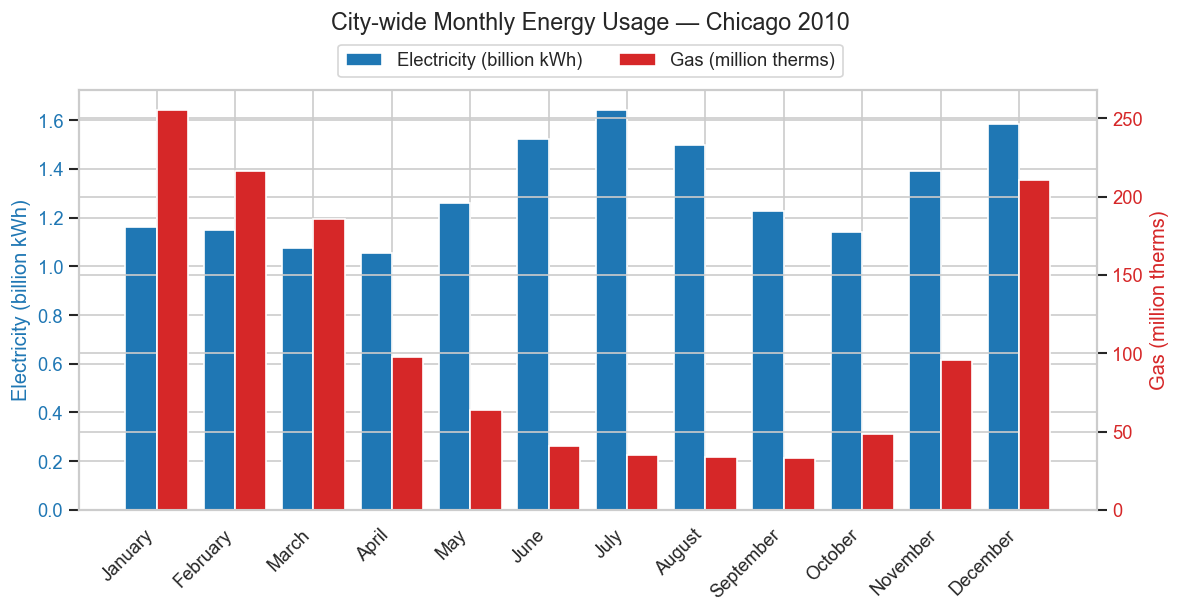

In [30]:
# ── Chart 1: City-wide monthly electricity vs. gas (side-by-side bar chart) ──
# This chart shows the total energy used across ALL of Chicago for each month.
# Electricity and gas are on different scales, so we use two y-axes (one on each side).

# Sum KWH and THERMS across all community areas for each month number.
# .reset_index() turns the grouped Month_Num back into a regular column.
city_monthly = df_long.groupby("Month_Num")[["KWH", "THERMS"]].sum().reset_index()

# Add a "Month" name column by reversing the month_order dictionary.
# {v: k for k, v in month_order.items()} flips keys and values: {1: "January", 2: "February", ...}
city_monthly["Month"] = city_monthly["Month_Num"].map(
    {v: k for k, v in month_order.items()}
)

# Create one figure with one set of axes (ax1).
# figsize=(10, 5) sets the chart to 10 inches wide and 5 inches tall.
fig, ax1 = plt.subplots(figsize=(10, 5))

# Define colors for each energy type.
color_kwh   = "#1f77b4"   # blue for electricity
color_therm = "#d62728"   # red for gas

# Draw the electricity bars on the LEFT y-axis (ax1).
# We shift each bar 0.2 units to the LEFT of the month number so the two bars don't overlap.
# Divide by 1e9 (1 billion) to convert raw kWh to "billion kWh" — easier to read.
ax1.bar(
    city_monthly["Month_Num"] - 0.2,   # x position: slightly left of center
    city_monthly["KWH"] / 1e9,          # y value: billion kWh
    width=0.4,                           # each bar is 0.4 units wide
    color=color_kwh,
    label="Electricity (billion kWh)",
)
ax1.set_ylabel("Electricity (billion kWh)", color=color_kwh)
# Color the left y-axis tick labels blue to match the bars.
ax1.tick_params(axis="y", labelcolor=color_kwh)
# Set x-axis ticks at positions 1–12 and label them with month names, rotated for readability.
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(city_monthly["Month"], rotation=45, ha="right")
ax1.set_xlabel("")   # no x-axis label needed — the month names are self-explanatory

# Create a SECOND y-axis on the RIGHT side that shares the same x-axis.
# ax1.twinx() creates a new axes object (ax2) that overlays ax1.
ax2 = ax1.twinx()

# Draw the gas bars on the RIGHT y-axis (ax2).
# Shift 0.2 units to the RIGHT so bars sit next to the electricity bars.
# Divide by 1e6 (1 million) to convert raw therms to "million therms".
ax2.bar(
    city_monthly["Month_Num"] + 0.2,   # x position: slightly right of center
    city_monthly["THERMS"] / 1e6,       # y value: million therms
    width=0.4,
    color=color_therm,
    label="Gas (million therms)",
)
ax2.set_ylabel("Gas (million therms)", color=color_therm)
# Color the right y-axis tick labels red to match the bars.
ax2.tick_params(axis="y", labelcolor=color_therm)

# Add a title above the chart. y=1.02 moves it slightly above the plot area.
fig.suptitle("City-wide Monthly Energy Usage — Chicago 2010", fontsize=14, y=1.02)
# Add a combined legend for both axes at the top center.
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.98))

# Automatically adjust spacing so nothing overlaps.
plt.tight_layout()
plt.show()

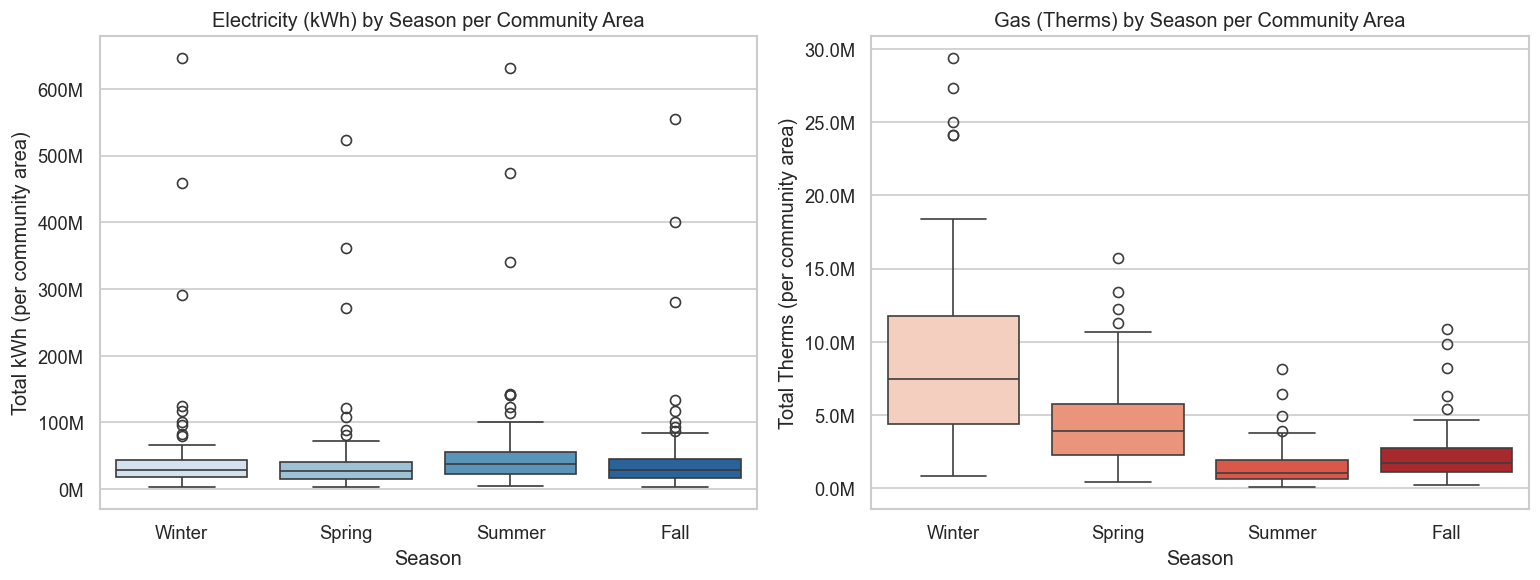

In [31]:
# ── Chart 2: Seasonal distribution across community areas (box plots) ────────
# A box plot shows the SPREAD of values across many neighborhoods for each season.
# The box covers the middle 50% of neighborhoods (25th–75th percentile).
# The line inside the box is the median (the "typical" neighborhood).
# The whiskers extend to the min/max (excluding outliers shown as dots).
# This lets us see not just the city average, but how much neighborhoods VARY.

# Define the order we want seasons displayed on the x-axis.
season_order = ["Winter", "Spring", "Summer", "Fall"]

# Create a figure with 1 row and 2 columns of subplots (side by side).
# sharey=False means each subplot can have its own y-axis scale.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

# --- Prepare data: sum monthly usage into seasonal totals per community area ---
# Group by both community area AND season, then sum the monthly KWH values.
# This gives us one row per (area, season) — 77 areas × 4 seasons = 308 rows.
seasonal_kwh = (
    df_long
    .groupby(["COMMUNITY AREA NAME", "Season"])["KWH"]
    .sum()
    .reset_index()
)

# Same for gas.
seasonal_therms = (
    df_long
    .groupby(["COMMUNITY AREA NAME", "Season"])["THERMS"]
    .sum()
    .reset_index()
)

# --- Draw the electricity box plot on the left subplot (axes[0]) ---
sns.boxplot(
    data=seasonal_kwh,
    x="Season",          # x-axis: season name
    y="KWH",             # y-axis: total electricity
    order=season_order,  # enforce our desired left-to-right order
    ax=axes[0],          # draw on the left subplot
    palette="Blues",     # use shades of blue
)
axes[0].set_title("Electricity (kWh) by Season per Community Area")
axes[0].set_ylabel("Total kWh (per community area)")
# Format y-axis labels as "5M" instead of "5000000" for readability.
# mticker.FuncFormatter takes a function: x is the tick value, _ is the position (ignored).
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
)

# --- Draw the gas box plot on the right subplot (axes[1]) ---
sns.boxplot(
    data=seasonal_therms,
    x="Season",
    y="THERMS",
    order=season_order,
    ax=axes[1],
    palette="Reds",      # use shades of red
)
axes[1].set_title("Gas (Therms) by Season per Community Area")
axes[1].set_ylabel("Total Therms (per community area)")
# Format as "1.5M" with one decimal place.
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

plt.tight_layout()
plt.show()

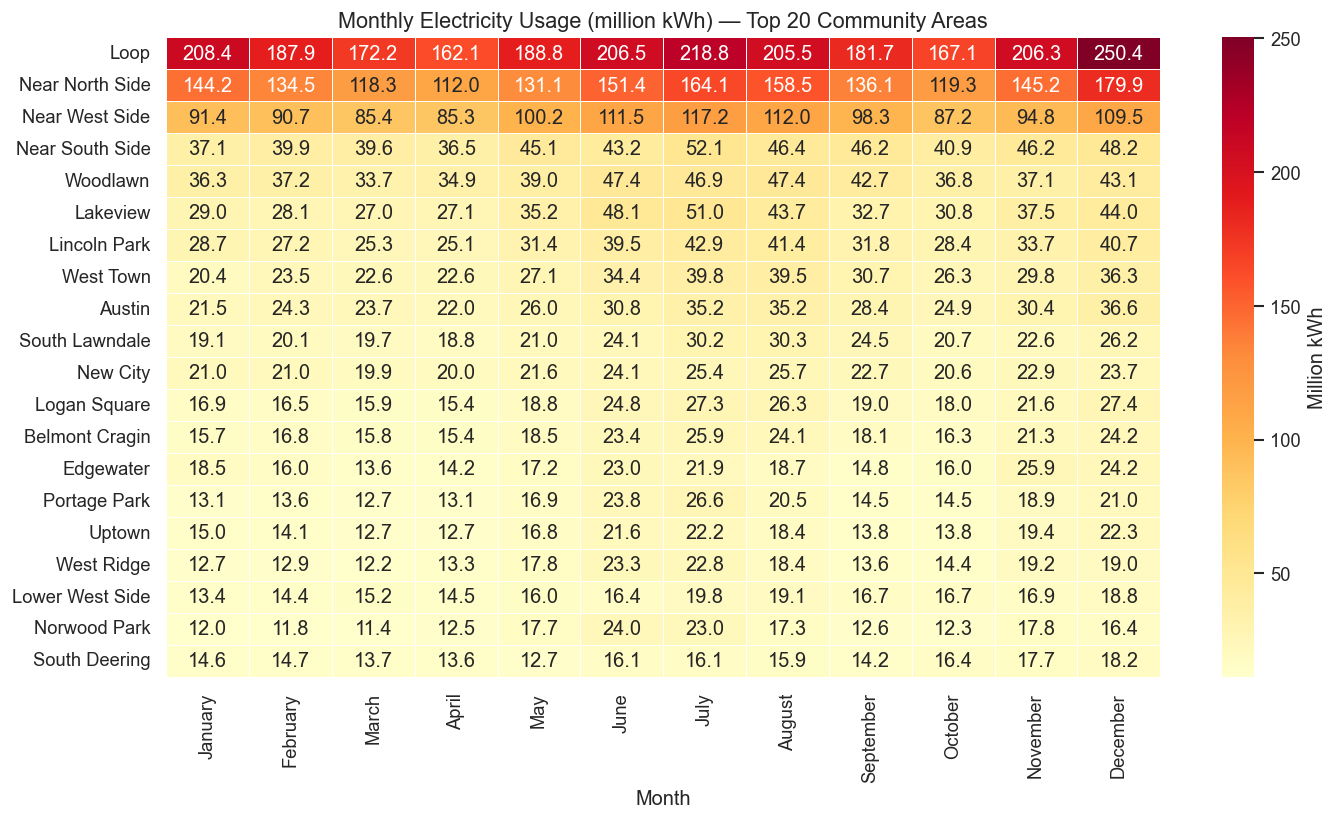

In [32]:
# ── Chart 3: Heatmap — monthly electricity for the top 20 community areas ────
# A heatmap uses color intensity to show values in a grid.
# Rows = community areas, Columns = months.
# Darker/warmer colors = more electricity used.
# This lets us see seasonal patterns AND compare neighborhoods at a glance.

# Find the 20 community areas with the highest TOTAL annual electricity.
# .nlargest(20, "TOTAL KWH") returns the 20 rows with the biggest TOTAL KWH values.
# We only keep the name column (we'll use it to filter df_long).
top20 = df_community.nlargest(20, "TOTAL KWH")["COMMUNITY AREA NAME"]

# Filter df_long to only the top 20 areas, then reshape into a matrix:
# rows = community areas, columns = month numbers, values = KWH.
# .pivot_table() is like a spreadsheet pivot — it rearranges the long data into a grid.
pivot_kwh = (
    df_long[df_long["COMMUNITY AREA NAME"].isin(top20)]  # keep only top 20 areas
    .pivot_table(
        index="COMMUNITY AREA NAME",   # each row is one community area
        columns="Month_Num",           # each column is one month (1–12)
        values="KWH",                  # the values in the grid are KWH
    )
)

# Replace numeric month numbers (1–12) with month names ("January"–"December").
# list(month_order.keys()) gives ["January", "February", ..., "December"].
# pivot_kwh.columns contains the month numbers; we use them as indices (c - 1) into the list.
pivot_kwh.columns = [list(month_order.keys())[c - 1] for c in pivot_kwh.columns]

# Reorder the rows to match the top20 ranking (highest total electricity first).
pivot_kwh = pivot_kwh.loc[top20]

# Create the heatmap.
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot_kwh / 1e6,          # divide by 1 million so numbers fit in the cells
    annot=True,                # show the numeric value inside each cell
    fmt=".1f",                 # format numbers with 1 decimal place (e.g. "3.2")
    cmap="YlOrRd",             # color map: yellow → orange → red (low → high)
    linewidths=0.5,            # thin white lines between cells for readability
    ax=ax,
    cbar_kws={"label": "Million kWh"},  # label the color bar on the right
)
ax.set_title("Monthly Electricity Usage (million kWh) — Top 20 Community Areas", fontsize=13)
ax.set_ylabel("")       # row labels are already the area names — no extra label needed
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

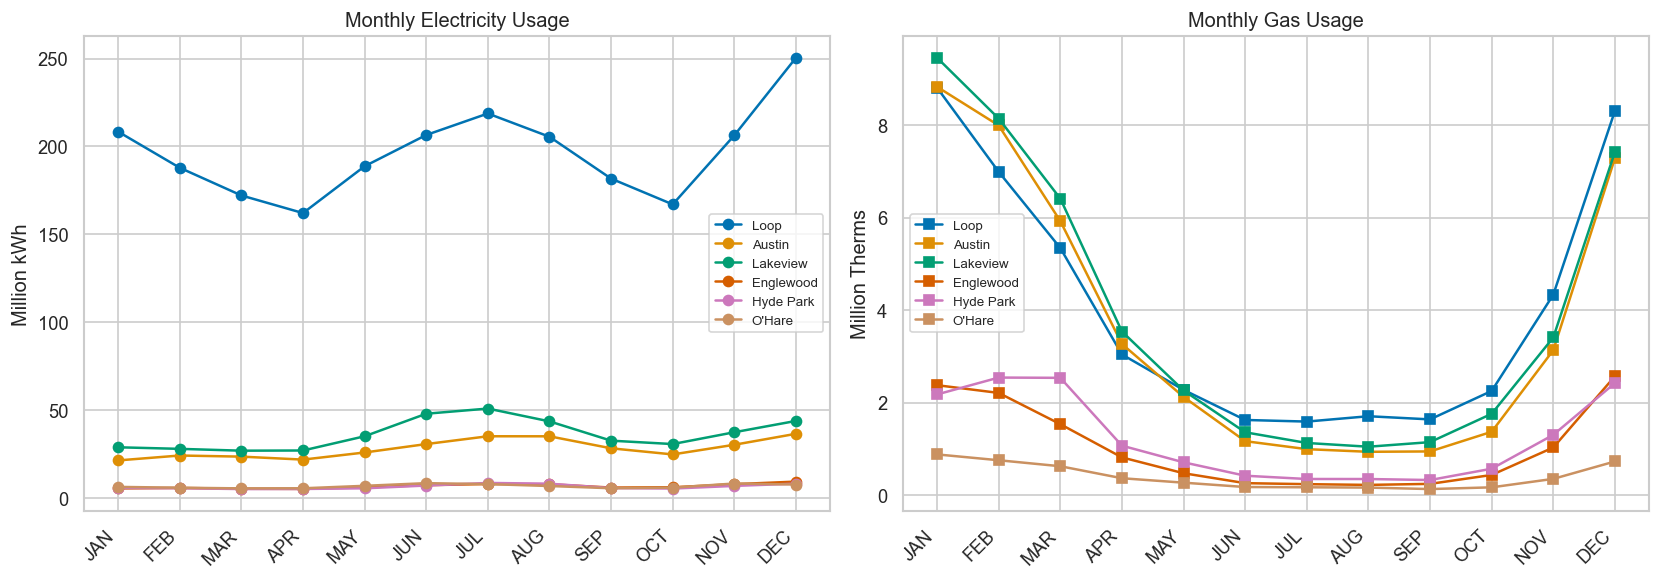

In [33]:
# ── Chart 4: Line plots — monthly profiles for 6 diverse neighborhoods ───────
# Line plots are great for showing how a value CHANGES over time (or over months).
# Each line represents one community area; we can compare their seasonal shapes.
# We chose neighborhoods that represent different parts of the city and building types:
#   Loop     = downtown commercial core
#   Austin   = large residential neighborhood on the west side
#   Lakeview = dense residential/mixed-use on the north lakefront
#   Englewood = residential neighborhood on the south side
#   Hyde Park = university neighborhood on the south lakefront
#   O'Hare   = airport area (industrial/commercial)

spotlight = ["Loop", "Austin", "Lakeview", "Englewood", "Hyde Park", "O'Hare"]

# Safety check: only keep names that actually exist in the dataset.
# This prevents errors if a name is spelled differently in the CSV.
spotlight_available = [s for s in spotlight if s in df_long["COMMUNITY AREA NAME"].values]

# Create a figure with 2 side-by-side subplots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loop over each selected neighborhood and draw its line on both subplots.
for area in spotlight_available:
    # Filter to just this area's rows and sort by month number (Jan → Dec).
    area_data = (
        df_long[df_long["COMMUNITY AREA NAME"] == area]
        .sort_values("Month_Num")
    )
    # Left subplot: electricity. marker="o" puts a circle dot at each data point.
    axes[0].plot(area_data["Month_Num"], area_data["KWH"] / 1e6, marker="o", label=area)
    # Right subplot: gas. marker="s" puts a square dot at each data point.
    axes[1].plot(area_data["Month_Num"], area_data["THERMS"] / 1e6, marker="s", label=area)

# Apply the same formatting to both subplots using zip().
# zip() pairs up the three lists element-by-element so we can loop over all three at once.
for ax, title, ylabel in zip(
    axes,
    ["Monthly Electricity Usage", "Monthly Gas Usage"],
    ["Million kWh", "Million Therms"],
):
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    # Set x-axis ticks at positions 1–12.
    ax.set_xticks(range(1, 13))
    # Label them with 3-letter abbreviations: m[:3] takes the first 3 characters of each month name.
    ax.set_xticklabels([m[:3] for m in MONTHS], rotation=45, ha="right")
    # Show the legend (area names) in a small font so it doesn't crowd the chart.
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

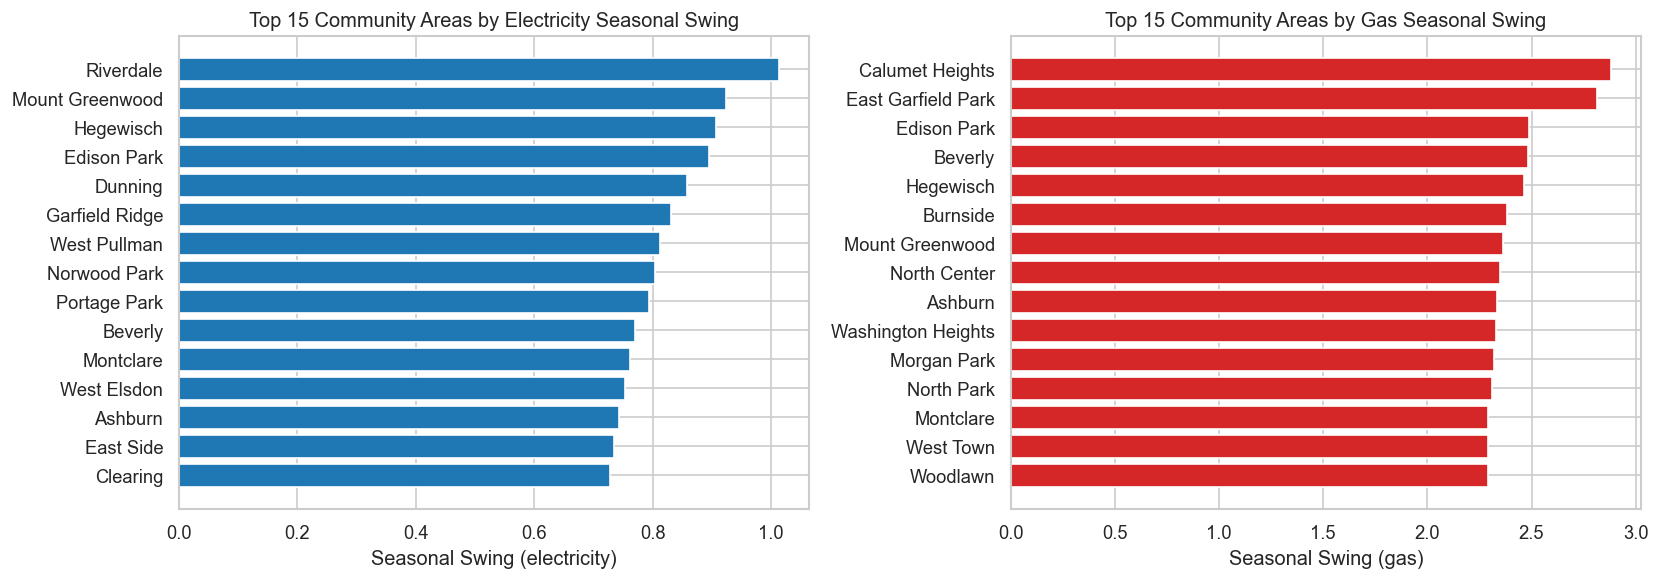

In [34]:
# ── Chart 5: Seasonal swing metric — which neighborhoods vary the most? ───────
# "Seasonal swing" measures how much a neighborhood's energy usage fluctuates
# between its busiest and quietest months, relative to its average usage.
#
# Formula:  swing = (max_month − min_month) / mean_month
#
# Example: if a neighborhood uses 10M kWh in July and 6M kWh in April,
#          and averages 8M kWh/month, its swing = (10-6)/8 = 0.5 (50% variation).
# A swing of 0 means perfectly flat (no seasonality).
# A higher swing means stronger seasonal variation.

# Calculate swing statistics for each community area.
# .agg() with named aggregations: new_col_name=("source_col", "function")
swing = (
    df_long
    .groupby("COMMUNITY AREA NAME")
    .agg(
        kwh_max=("KWH", "max"),     # highest monthly electricity
        kwh_min=("KWH", "min"),     # lowest monthly electricity
        kwh_mean=("KWH", "mean"),   # average monthly electricity
        therm_max=("THERMS", "max"),
        therm_min=("THERMS", "min"),
        therm_mean=("THERMS", "mean"),
    )
)

# Calculate the swing ratio for electricity and gas.
swing["KWH_swing"]   = (swing["kwh_max"]   - swing["kwh_min"])   / swing["kwh_mean"]
swing["THERM_swing"] = (swing["therm_max"] - swing["therm_min"]) / swing["therm_mean"]

# .reset_index() moves "COMMUNITY AREA NAME" from the row index back to a regular column.
swing = swing.reset_index()

# Create two horizontal bar charts side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left chart: electricity swing ---
# .sort_values("KWH_swing") sorts ascending (smallest first).
# .tail(15) keeps the last 15 rows — the 15 HIGHEST swing values.
# .barh() draws horizontal bars (area names on y-axis, swing value on x-axis).
axes[0].barh(
    swing.sort_values("KWH_swing").tail(15)["COMMUNITY AREA NAME"],  # y: area names
    swing.sort_values("KWH_swing").tail(15)["KWH_swing"],            # x: swing values
    color="#1f77b4",   # blue
)
axes[0].set_xlabel("Seasonal Swing (electricity)")
axes[0].set_title("Top 15 Community Areas by Electricity Seasonal Swing")

# --- Right chart: gas swing ---
axes[1].barh(
    swing.sort_values("THERM_swing").tail(15)["COMMUNITY AREA NAME"],
    swing.sort_values("THERM_swing").tail(15)["THERM_swing"],
    color="#d62728",   # red
)
axes[1].set_xlabel("Seasonal Swing (gas)")
axes[1].set_title("Top 15 Community Areas by Gas Seasonal Swing")

plt.tight_layout()
plt.show()

### Key Patterns from EDA

1. **Electricity peaks in summer** (July–August) consistent with air-conditioning demand, while **gas peaks in winter** (January–February) driven by heating.
2. The seasonal profile is **not uniform** across the city — some community areas (e.g., Loop, O'Hare) show much flatter electricity curves due to commercial/industrial loads, while residential areas have sharper seasonal swings.
3. Gas usage is **far more seasonal** than electricity; the winter-to-summer ratio for therms is typically 5–10×, whereas electricity varies by roughly 1.5–2×.
4. The **seasonal swing metric** reveals which neighborhoods are most sensitive to weather — these are prime targets for weatherization and efficiency programs.

## Statistical Tests & Model Design

In [35]:
# ── Test 1: Kruskal-Wallis test — does energy usage differ by season? ────────
#
# A statistical test helps us decide whether a pattern we see in the data is
# REAL (statistically significant) or could just be random chance.
#
# We use the Kruskal-Wallis test because:
#   - It compares 3+ groups (we have 4 seasons).
#   - It is "non-parametric" — it does NOT assume the data is normally distributed.
#   - Energy data is often skewed (a few very large buildings pull the average up),
#     so non-parametric tests are safer than a standard ANOVA.
#
# Null hypothesis (H₀): The distribution of energy usage is the SAME in all 4 seasons.
# Alternative hypothesis (H₁): At least one season has a different distribution.
#
# If the p-value < 0.05, we reject H₀ and conclude there IS a seasonal difference.
# (p-value = probability of seeing our data if H₀ were true; small p = strong evidence against H₀)

# Build a list of 4 arrays — one per season — containing all KWH values for that season.
# .dropna() removes any missing values so the test doesn't error out.
groups_kwh = [
    df_long[df_long["Season"] == s]["KWH"].dropna()
    for s in season_order   # season_order = ["Winter", "Spring", "Summer", "Fall"]
]

# Run the Kruskal-Wallis test.
# *groups_kwh "unpacks" the list so the function receives 4 separate arguments.
# It returns two values: the H-statistic (test score) and the p-value.
stat_kwh, p_kwh = stats.kruskal(*groups_kwh)

print("=== Kruskal-Wallis: Electricity (KWH) across Seasons ===")
print(f"  H-statistic : {stat_kwh:.2f}")
# :.2e formats the p-value in scientific notation (e.g. 1.23e-10) — useful for tiny numbers.
print(f"  p-value     : {p_kwh:.2e}")
# Interpret the result: if p < 0.05 we reject the null hypothesis.
print(f"  → {'Reject' if p_kwh < 0.05 else 'Fail to reject'} H₀ at α = 0.05\n")

# ── Repeat the same test for gas (THERMS) ────────────────────────────────────
groups_therm = [
    df_long[df_long["Season"] == s]["THERMS"].dropna()
    for s in season_order
]
stat_therm, p_therm = stats.kruskal(*groups_therm)

print("=== Kruskal-Wallis: Gas (THERMS) across Seasons ===")
print(f"  H-statistic : {stat_therm:.2f}")
print(f"  p-value     : {p_therm:.2e}")
print(f"  → {'Reject' if p_therm < 0.05 else 'Fail to reject'} H₀ at α = 0.05")

=== Kruskal-Wallis: Electricity (KWH) across Seasons ===
  H-statistic : 28.98
  p-value     : 2.26e-06
  → Reject H₀ at α = 0.05

=== Kruskal-Wallis: Gas (THERMS) across Seasons ===
  H-statistic : 403.38
  p-value     : 4.09e-87
  → Reject H₀ at α = 0.05


In [36]:
# ── Test 2: Pairwise Mann-Whitney U tests — which season pairs differ? ────────
#
# The Kruskal-Wallis test tells us "at least one season is different" but not WHICH ones.
# We follow up with pairwise Mann-Whitney U tests — comparing every pair of seasons.
#
# Mann-Whitney U compares two groups and asks: "Are values in group A generally
# larger (or smaller) than values in group B?"
# It is the non-parametric equivalent of a two-sample t-test.
#
# With 4 seasons there are 6 possible pairs: (Winter/Spring, Winter/Summer, etc.)
# Running 6 tests increases the chance of a false positive, so we apply the
# Bonferroni correction: divide the significance threshold (0.05) by the number
# of tests (6), giving a stricter threshold of 0.0083.

# itertools.combinations generates all unique pairs without repeats.
# combinations(["A","B","C"], 2) → [("A","B"), ("A","C"), ("B","C")]
from itertools import combinations

print("=== Pairwise Mann-Whitney U tests (electricity kWh) ===")
# Print a formatted table header. The numbers control column widths:
# <25 = left-aligned in 25 characters, >12 = right-aligned in 12 characters.
print(f"{'Pair':<25} {'U-stat':>12} {'p-value':>12} {'Significant?':>14}")
print("-" * 65)   # separator line

# Loop over every unique pair of seasons.
for s1, s2 in combinations(season_order, 2):
    # Get all KWH values for each season in the pair.
    g1 = df_long[df_long["Season"] == s1]["KWH"].dropna()
    g2 = df_long[df_long["Season"] == s2]["KWH"].dropna()

    # Run the Mann-Whitney U test.
    # alternative="two-sided" means we test for any difference (not just one direction).
    u_stat, p_val = stats.mannwhitneyu(g1, g2, alternative="two-sided")

    # Apply Bonferroni correction: mark as significant only if p < 0.05/6.
    sig = "Yes*" if p_val < (0.05 / 6) else "No"

    # Print one row of the results table.
    # :,.0f formats the U-statistic with commas and no decimal places.
    print(f"{s1 + ' vs ' + s2:<25} {u_stat:>12,.0f} {p_val:>12.2e} {sig:>14}")

# Remind the reader what the corrected threshold is.
print(f"\n* Bonferroni-corrected α = {0.05/6:.4f}")

=== Pairwise Mann-Whitney U tests (electricity kWh) ===
Pair                            U-stat      p-value   Significant?
-----------------------------------------------------------------
Winter vs Spring                28,819     1.36e-01             No
Winter vs Summer                21,367     2.13e-04           Yes*
Winter vs Fall                  26,336     8.11e-01             No
Spring vs Summer                19,344     3.18e-07           Yes*
Spring vs Fall                  24,222     8.67e-02             No
Summer vs Fall                  31,821     3.41e-04           Yes*

* Bonferroni-corrected α = 0.0083


=== Spearman Correlation: Average Building Age vs. Seasonal Swing ===
  Electricity swing:  ρ = -0.116,  p = 0.3159
  Gas swing:          ρ = -0.011,  p = 0.9235


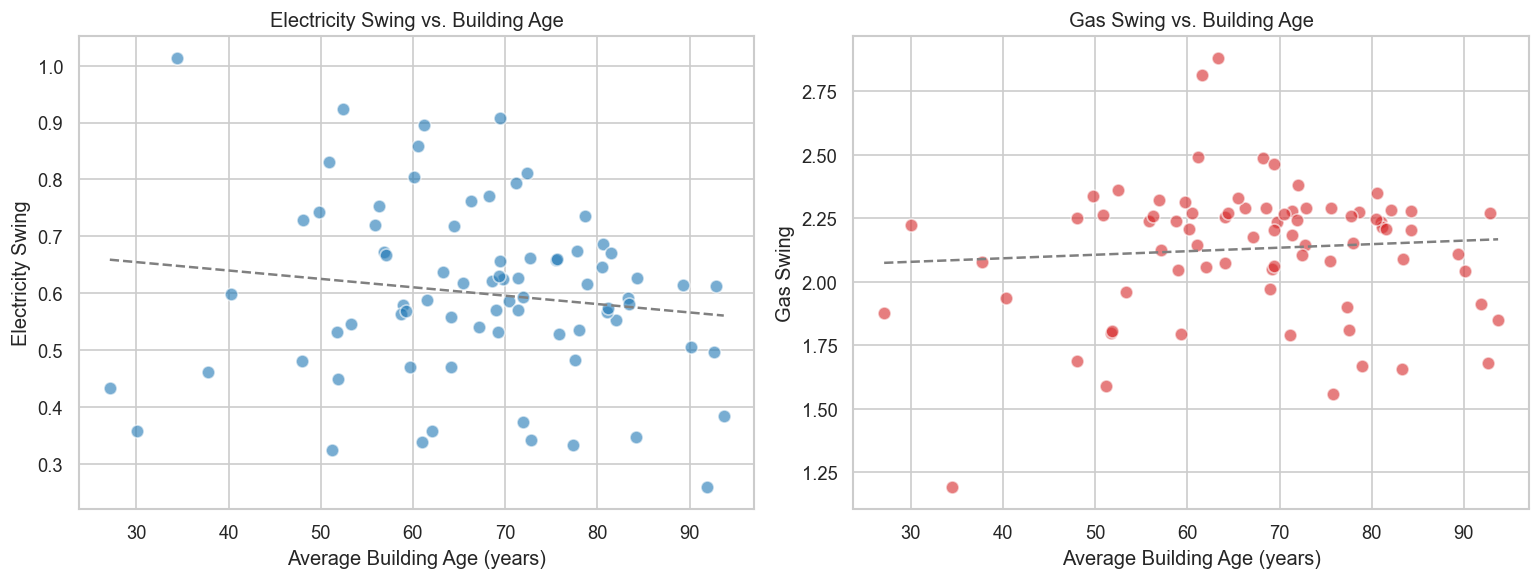

In [37]:
# ── Test 3: Spearman correlation — does building age predict seasonal swing? ──
#
# We hypothesized that neighborhoods with OLDER buildings might have LARGER seasonal
# swings — because older buildings tend to have worse insulation, so they heat up
# more in summer and lose heat faster in winter.
#
# A correlation measures how strongly two variables move together:
#   ρ (rho) close to +1 → strong positive relationship (older = more swing)
#   ρ close to -1 → strong negative relationship (older = less swing)
#   ρ close to  0 → no relationship
#
# We use Spearman correlation (rank-based) rather than Pearson (value-based)
# because our data is not normally distributed.

# Merge the swing DataFrame with building age and other community-area features.
# .merge() joins two DataFrames on a shared column — like a SQL JOIN.
swing_merged = swing.merge(
    df_community[[
        "COMMUNITY AREA NAME",
        "AVERAGE BUILDING AGE",
        "OCCUPIED UNITS",
        "TOTAL POPULATION",
    ]],
    on="COMMUNITY AREA NAME",
)

# Drop rows where building age is missing before running the correlation.
# We need both variables to be present for the same row.
valid_rows = swing_merged["AVERAGE BUILDING AGE"].notna()

# stats.spearmanr() returns (correlation_coefficient, p_value).
# We pass the building age column and the swing column for the same valid rows.
r_kwh,   p_r_kwh   = stats.spearmanr(
    swing_merged.loc[valid_rows, "AVERAGE BUILDING AGE"],
    swing_merged.loc[valid_rows, "KWH_swing"],
)
r_therm, p_r_therm = stats.spearmanr(
    swing_merged.loc[valid_rows, "AVERAGE BUILDING AGE"],
    swing_merged.loc[valid_rows, "THERM_swing"],
)

print("=== Spearman Correlation: Average Building Age vs. Seasonal Swing ===")
# ρ is the Greek letter rho — the standard symbol for Spearman correlation.
print(f"  Electricity swing:  ρ = {r_kwh:.3f},  p = {p_r_kwh:.4f}")
print(f"  Gas swing:          ρ = {r_therm:.3f},  p = {p_r_therm:.4f}")

# ── Scatter plots with trend lines ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loop over both energy types simultaneously using zip().
for ax, col, label, color in zip(
    axes,
    ["KWH_swing", "THERM_swing"],
    ["Electricity Swing", "Gas Swing"],
    ["#1f77b4", "#d62728"],
):
    # Draw one dot per community area.
    # alpha=0.6 makes dots slightly transparent so overlapping dots are visible.
    # edgecolors="w" adds a thin white border around each dot.
    # s=60 sets the dot size.
    ax.scatter(
        swing_merged["AVERAGE BUILDING AGE"],
        swing_merged[col],
        alpha=0.6, edgecolors="w", s=60, color=color,
    )

    # Fit a linear trend line through the valid (non-missing) data points.
    # np.polyfit(x, y, 1) fits a degree-1 polynomial (a straight line) and returns
    # the coefficients [slope, intercept].
    z = np.polyfit(
        swing_merged.loc[valid_rows, "AVERAGE BUILDING AGE"],
        swing_merged.loc[valid_rows, col],
        1,   # degree 1 = straight line
    )

    # Create 100 evenly-spaced x values from min to max building age.
    # np.linspace(start, stop, num) generates `num` equally-spaced points.
    x_line = np.linspace(
        swing_merged["AVERAGE BUILDING AGE"].min(),
        swing_merged["AVERAGE BUILDING AGE"].max(),
        100,
    )

    # np.polyval(coefficients, x) evaluates the polynomial at each x value.
    # "--" makes a dashed line; gray color keeps it visually subtle.
    ax.plot(x_line, np.polyval(z, x_line), "--", color="gray")

    ax.set_xlabel("Average Building Age (years)")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs. Building Age")

plt.tight_layout()
plt.show()

## Results & Interpretation

### What did we find?

| Finding | Detail |
|---|---|
| **Seasonal electricity pattern** | City-wide electricity peaks in July–August (summer cooling) and troughs in spring/fall. The Kruskal-Wallis test confirms the seasonal differences are statistically significant. |
| **Seasonal gas pattern** | Natural gas consumption is **dramatically** more seasonal — winter usage can be 5–10× higher than summer. The statistical tests confirm this at very high significance. |
| **Variation across the city** | The seasonal swing is **not uniform**. Community areas dominated by commercial buildings (e.g., Loop, O'Hare) show flatter electricity profiles, while heavily residential areas show sharper summer peaks. |
| **Building age effect** | The Spearman correlation tests whether older buildings have larger seasonal swings (potentially due to poorer insulation). The direction and significance of this relationship can guide targeted retrofit programs. |

### Do we support the hypothesis?

**Yes.** Energy usage exhibits a strong seasonal pattern for both electricity and gas, and the magnitude of the seasonal swing differs meaningfully across community areas. The hypothesis that building characteristics contribute to these differences is directionally supported by the building age correlation, though the relationship is moderate and other factors (income, building density, commercial mix) also play a role.

## Limitations & Next Steps

### Limitations

1. **Single year of data (2010).** We cannot distinguish seasonal patterns from year-specific anomalies (e.g., an unusually hot summer). Multi-year data would strengthen conclusions.
2. **No weather data.** Without actual temperature records, we infer that summer electricity peaks are due to cooling and winter gas peaks are due to heating, but we cannot model this directly.
3. **Coverage gaps.** The dataset covers ~68% of electricity and ~81% of gas usage. Missing accounts may introduce bias, particularly in areas with more small buildings.
4. **Aggregation effects.** Census blocks with < 4 accounts are rolled up to the community-area level, which could slightly distort per-block comparisons.
5. **No income / socioeconomic controls.** Lower-income households may under-consume energy (e.g., not running AC), which would compress the measured seasonal swing without reflecting actual demand.

### Next Steps

- **Incorporate weather data** (e.g., Heating Degree Days / Cooling Degree Days from NOAA) to model the temperature–energy relationship directly.
- **Multi-year analysis** using the City of Chicago's updated energy datasets to distinguish trend from seasonality.
- **Regression modeling** predicting seasonal swing from building age, housing type, population density, and renter percentage.
- **Geospatial visualization** — map community areas by seasonal swing to identify spatial clusters for targeted efficiency programs.
- **Equity analysis** — overlay energy burden (energy cost as % of household income) with seasonal swing to identify vulnerable communities.